In [173]:
import torch
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tqdm import tqdm

In [174]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\d1990\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\d1990\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [175]:
corpus_raw = [
    "Inflation continues to be a major concern for the global economy. Central banks are raising interest rates to combat rising prices.",
    "Technology stocks experienced a downturn as investors worried about future growth prospects. The market reacted negatively to recent earning reports.",
    "Scientists discovered a new exoplanet with conditions that could potentially support life. Further research is needed to confirm its habitability.",
    "The new AI model can generate realistic text and images based on simple prompts. It represents a significant leap forward in machine learning.",
    "Climate change discussions dominated the summit, with world leaders pledging to reduce carbon emissions. New regulations are expected to accelerate the transition to renewable energy."
]

In [176]:
num_topics = 3
#below are parameters for Dirichlet distributions
alpha = torch.full((num_topics,), 0.1) 
beta = torch.full((1,), 0.1)

In [177]:
stop_words = set(stopwords.words('english'))

In [178]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [179]:
def preprocess(docs):
    result = []
    stop_words = set(stopwords.words('english'))

    for text in docs:
        #convert to lowercase, then replace non alpha chars with empty
        text = re.sub(r'[^a-z\s]', '', text.lower())
        tokens = word_tokenize(text)
        # remove stopwords
        filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
        result.append(filtered_tokens)
    return result

In [180]:
processed_docs = preprocess(corpus_raw)

In [181]:
vocab = sorted(list(set(word for doc in processed_docs for word in doc)))
vocab_size = len(vocab)


#create a mapping from characters to integers
stoi = {s: i for i, s in enumerate(vocab)}
itos = {i : s for s, i in stoi.items()}
encode = lambda s : [stoi[c] for c in s] #encoder: take a sting, output a list of integers
decode = lambda l: ' '.join([itos[i] for i in l]) #decoder: take a list of integers, output a string

In [182]:
vocab_size

74

In [183]:
#doc and word mapping
word_ids = []
doc_indices = []


for idx, text in enumerate(processed_docs):
    for word in text:
        word_ids.append(stoi[word])
        doc_indices.append(idx)

num_tokens = len(word_ids) 

In [184]:
#gibbs sampling
# randomly assign a topic for each word or torken
assignments = torch.randint(0, num_topics, (num_tokens, ))

In [185]:
assignments[:5]

tensor([1, 1, 2, 1, 1])

In [186]:
#init cnt matrices
num_docs = len(processed_docs)
cnt_dk = torch.zeros(num_docs, num_topics) # document topic counts
cnt_wk = torch.zeros(vocab_size, num_topics) # word topic counts
cnt_k = torch.zeros(num_topics) # words / topic

In [187]:
#initial counts
for i in range(num_tokens):
    topic_id = assignments[i].item()
    doc_idx = doc_indices[i]
    word_idx = word_ids[i]
        
    cnt_dk[doc_idx, topic_id] += 1
    cnt_wk[word_idx, topic_id] += 1
    cnt_k[topic_id] += 1

#Gibbs sampling initializations done

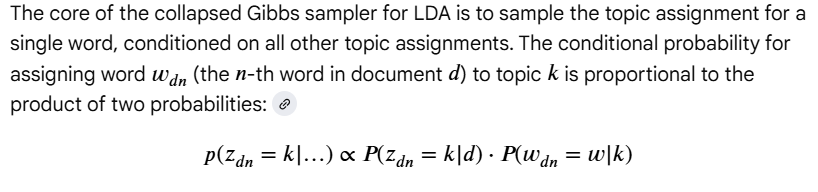


In [188]:
max_steps = 2000
burn_in = 1000
thinning = 10
sampled_assignments = []

print("Starting gibss sampling")
for step in tqdm(range(max_steps)):
    for i in range(num_tokens):
        doc_idx = doc_indices[i]
        word_idx = word_ids[i]
        old_topic_id = assignments[i].item()
        #exclude current word topic from assignments
        cnt_dk[doc_idx, old_topic_id] -= 1
        cnt_wk[word_idx, old_topic_id] -= 1
        cnt_k[old_topic_id] -= 1


        if torch.any(cnt_dk < 0) or torch.any(cnt_wk < 0) or torch.any(cnt_k < 0):
            print(cnt_dk[doc_idx, old_topic_id], cnt_wk[word_idx, old_topic_id],cnt_k[old_topic_id] )
            print("Negative count detected! Debugging...")
            break

        #conditional proability calculation
        # p(z_i = k | ...) = p(topic|doc) * p(word|topic)
        p_k = (cnt_dk[doc_idx] + alpha) * ((cnt_wk[word_idx] + beta) / (cnt_k + vocab_size * beta))

        #sample a new topic
        p_k = p_k / torch.sum(p_k) #normalize
        new_topic_id = torch.multinomial(p_k, 1).item()
        assignments[i] = new_topic_id

        #update new topic cnt
        cnt_dk[doc_idx, new_topic_id] += 1
        cnt_wk[word_idx, new_topic_id] += 1
        cnt_k[new_topic_id] += 1

        # Store samples after burn-in and thinning
    if step >= burn_in and (step - burn_in) % thinning == 0:
        sampled_assignments.append(assignments.clone())

print("\nGibbs sampling complete.")


Starting gibss sampling


100%|██████████| 2000/2000 [00:17<00:00, 113.45it/s]


Gibbs sampling complete.


In [189]:
#derive final distributions
avg_cnt_dk = torch.zeros_like(cnt_dk)
avg_cnt_wk = torch.zeros_like(cnt_wk)

for item in sampled_assignments:
    temp_cnt_dk = torch.zeros_like(cnt_dk)
    temp_cnt_wk = torch.zeros_like(cnt_wk)

    for i in range(num_tokens):
        doc_idx = doc_indices[i]
        word_idx= word_ids[i]
        topic_id = assignments[i].item()
        temp_cnt_dk[doc_idx, topic_id] += 1
        temp_cnt_wk[word_idx, topic_id] += 1
    
    avg_cnt_dk += temp_cnt_dk
    avg_cnt_wk += temp_cnt_wk

avg_cnt_dk /= len(sampled_assignments)
avg_cnt_wk /= len(sampled_assignments)

In [190]:
beta2 = (avg_cnt_wk + beta) / (torch.sum(avg_cnt_wk, dim=0, keepdim=True) + vocab_size * beta)
theta = (avg_cnt_dk + alpha) / (torch.sum(avg_cnt_dk, dim=1, keepdim=True) + num_topics * alpha)


In [193]:
print("\nEstimated Topic-Word Distribution (Beta):")
for topic_idx in range(num_topics):
    print(f"Topic {topic_idx + 1}:")
    top_words_indices = torch.argsort(beta2[:, topic_idx], descending=True)[:5]
    top_words = [itos[idx.item()] for idx in top_words_indices]
    print(f"  Top words: {', '.join(top_words)}")

print("\nEstimated Document-Topic Distribution (Theta):")
for doc_idx in range(num_docs):
    print(f"Document {doc_idx + 1}: {corpus_raw[doc_idx][:50]}...")
    topic_distribution = theta[doc_idx]
    top_topic = torch.argmax(topic_distribution).item()
    print(f"  Dominant Topic: {top_topic + 1} (Probability: {topic_distribution[top_topic].item():.2f})")
    print(f"  All topic probabilities: {topic_distribution.detach().numpy()}")


Estimated Topic-Word Distribution (Beta):
Topic 1:
  Top words: new, accelerate, discovered, discussions, dominated
Topic 2:
  Top words: concern, interest, banks, based, exoplanet
Topic 3:
  Top words: earning, ai, future, generate, images

Estimated Document-Topic Distribution (Theta):
Document 1: Inflation continues to be a major concern for the ...
  Dominant Topic: 2 (Probability: 0.99)
  All topic probabilities: [0.00699301 0.986014   0.00699301]
Document 2: Technology stocks experienced a downturn as invest...
  Dominant Topic: 3 (Probability: 0.99)
  All topic probabilities: [0.00653595 0.00653595 0.9869281 ]
Document 3: Scientists discovered a new exoplanet with conditi...
  Dominant Topic: 1 (Probability: 0.76)
  All topic probabilities: [0.7593985 0.2330827 0.0075188]
Document 4: The new AI model can generate realistic text and i...
  Dominant Topic: 2 (Probability: 0.56)
  All topic probabilities: [0.00613497 0.55828226 0.43558285]
Document 5: Climate change discussions do